# Support Vector Machines aim to find the best decision boundary (called a hyperplane) that separates different classes in the dataset with the maximum margin.

# Step 1: Generate a Linearly Separable Dataset

We create a simple synthetic dataset with two classes using `make_blobs`.  
This data is designed to be linearly separable, meaning a straight line (hyperplane) can perfectly divide the classes.

This setup helps us understand how a linear SVM finds the optimal separating hyperplane.


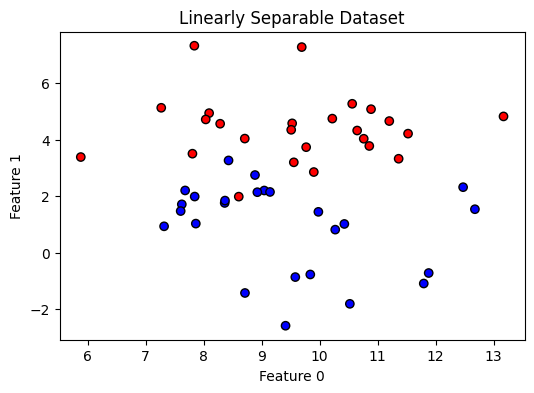

In [1]:
# Step 1: Import libraries and create dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create a synthetic 2-class, 2-feature dataset
X, y = make_blobs(centers=2, random_state=4, n_samples=50, cluster_std=1.5)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolor='k')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Linearly Separable Dataset")
plt.show()


# Step 2: Train a Linear SVM and Visualize the Decision Boundary

We train an SVM with a **linear kernel** to find the hyperplane that maximizes the margin between classes.

Mathematically, SVM solves:

$$
\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2
\quad \text{s.t.} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1
$$

The decision boundary, margin lines, and support vectors are visualized.

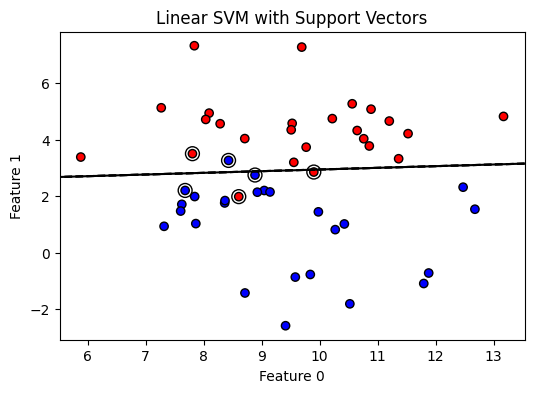

In [2]:
# Step 2: Train a linear SVM and visualize decision boundary
from sklearn.svm import SVC
import numpy as np

# Train the SVM with a linear kernel
svm = SVC(kernel='linear', C=1e10)  # C=1e10 to minimize regularization
svm.fit(X, y)

# Create a grid to evaluate the model
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolor='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])

# Plot support vectors
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=100, linewidth=1, facecolors='none', edgecolors='k')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Linear SVM with Support Vectors")
plt.show()


# Step 3: Understand the Effect of the Regularization Parameter \(C\)

Parameter \(C\) controls the trade-off between maximizing margin and minimizing classification errors.

- Large \(C\): Less margin violations, potentially overfitting.
- Small \(C\): Allows margin violations, wider margin, better generalization.

Soft margin SVM solves:

$$
\min_{\mathbf{w}, b, \xi} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum \xi_i
\quad \text{s.t.} \quad y_i (\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i
$$

We compare decision boundaries for different \(C\) values.


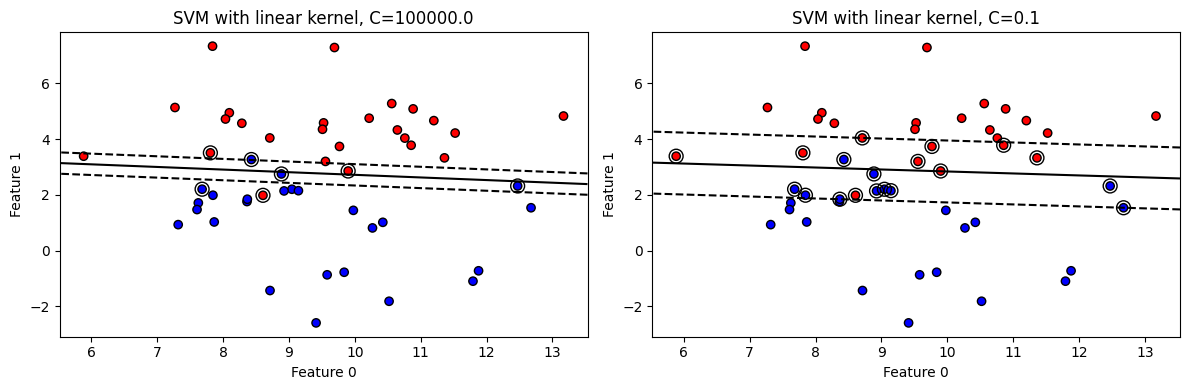

In [3]:
# Step 3: Visualizing effect of different C values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, C_val in zip(axes, [1e5, 0.1]):
    svm = SVC(kernel='linear', C=C_val)
    svm.fit(X, y)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')
    ax.set_title(f"SVM with linear kernel, C={C_val}")
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

    # Decision function grid
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = svm.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])

    # Support vectors
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')

plt.tight_layout()
plt.show()


# Step 4: Create a Non-Linearly Separable Dataset

We generate a dataset (concentric circles) that cannot be separated by a straight line in 2D.

This simulates real-world complex data and motivates the need for non-linear decision boundaries and kernels.


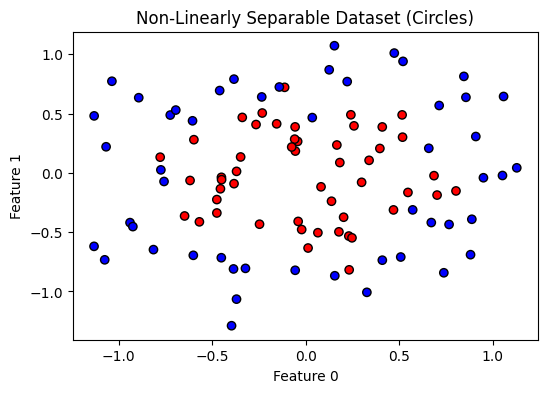

In [4]:
from sklearn.datasets import make_circles

# Create dataset: concentric circles (non-linearly separable)
X, y = make_circles(noise=0.2, factor=0.5, random_state=1)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Non-Linearly Separable Dataset (Circles)")
plt.show()


# Visualizing the Data in an Expanded 3D Feature Space

We manually transform the original 2D data by adding a new feature $$ z = x_0^2 + x_1^2 $$
which maps the non-linearly separable data into 3D.  

In this new space, the data becomes linearly separable by a plane,  
illustrating the intuition behind the kernel trick used by SVMs.


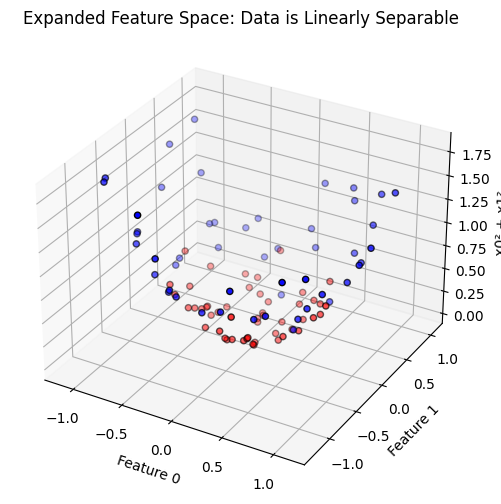

In [6]:
from mpl_toolkits.mplot3d import Axes3D

# Create 3D feature by manually expanding data
X_new = np.hstack([X, (X[:, 0] ** 2 + X[:, 1] ** 2).reshape(-1, 1)])

# Plot in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=y, cmap=plt.cm.bwr, edgecolor='k')
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("x0² + x1²")
ax.set_title("Expanded Feature Space: Data is Linearly Separable")
plt.show()


# Step 5: Train an SVM with RBF Kernel for Non-Linear Boundaries

The RBF kernel implicitly maps data to a higher-dimensional space, enabling linear separation there.

Kernel function:

$$
K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2)
$$

We train the SVM with this kernel and visualize the non-linear decision boundary.


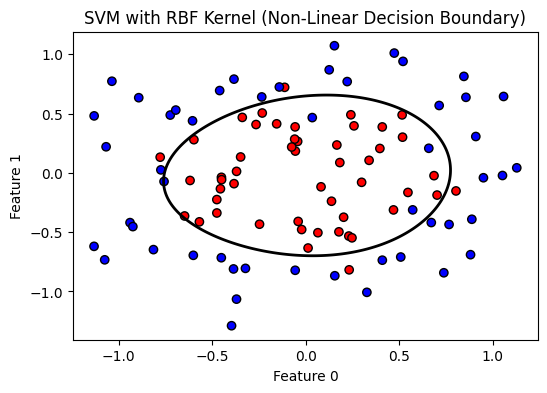

In [5]:
# Step 5: Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma=1)
svm_rbf.fit(X, y)

# Visualize the decision boundary
plt.figure(figsize=(6, 4))

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')

# Create grid for decision function
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 500)
yy = np.linspace(ylim[0], ylim[1], 500)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_rbf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
plt.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')  # Only decision boundary
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("SVM with RBF Kernel (Non-Linear Decision Boundary)")
plt.show()


# Step 6: Explore the Effect of Hyperparameters \(C\) and \(\gamma\) in RBF Kernel

- \(\gamma\) controls the radius of influence of points:  
  - Low \(\gamma\) → smoother boundary  
  - High \(\gamma\) → complex, wiggly boundary  

- \(C\) balances margin size vs. classification error.

We visualize decision boundaries for different \((C, \gamma)\) pairs to understand their effect.


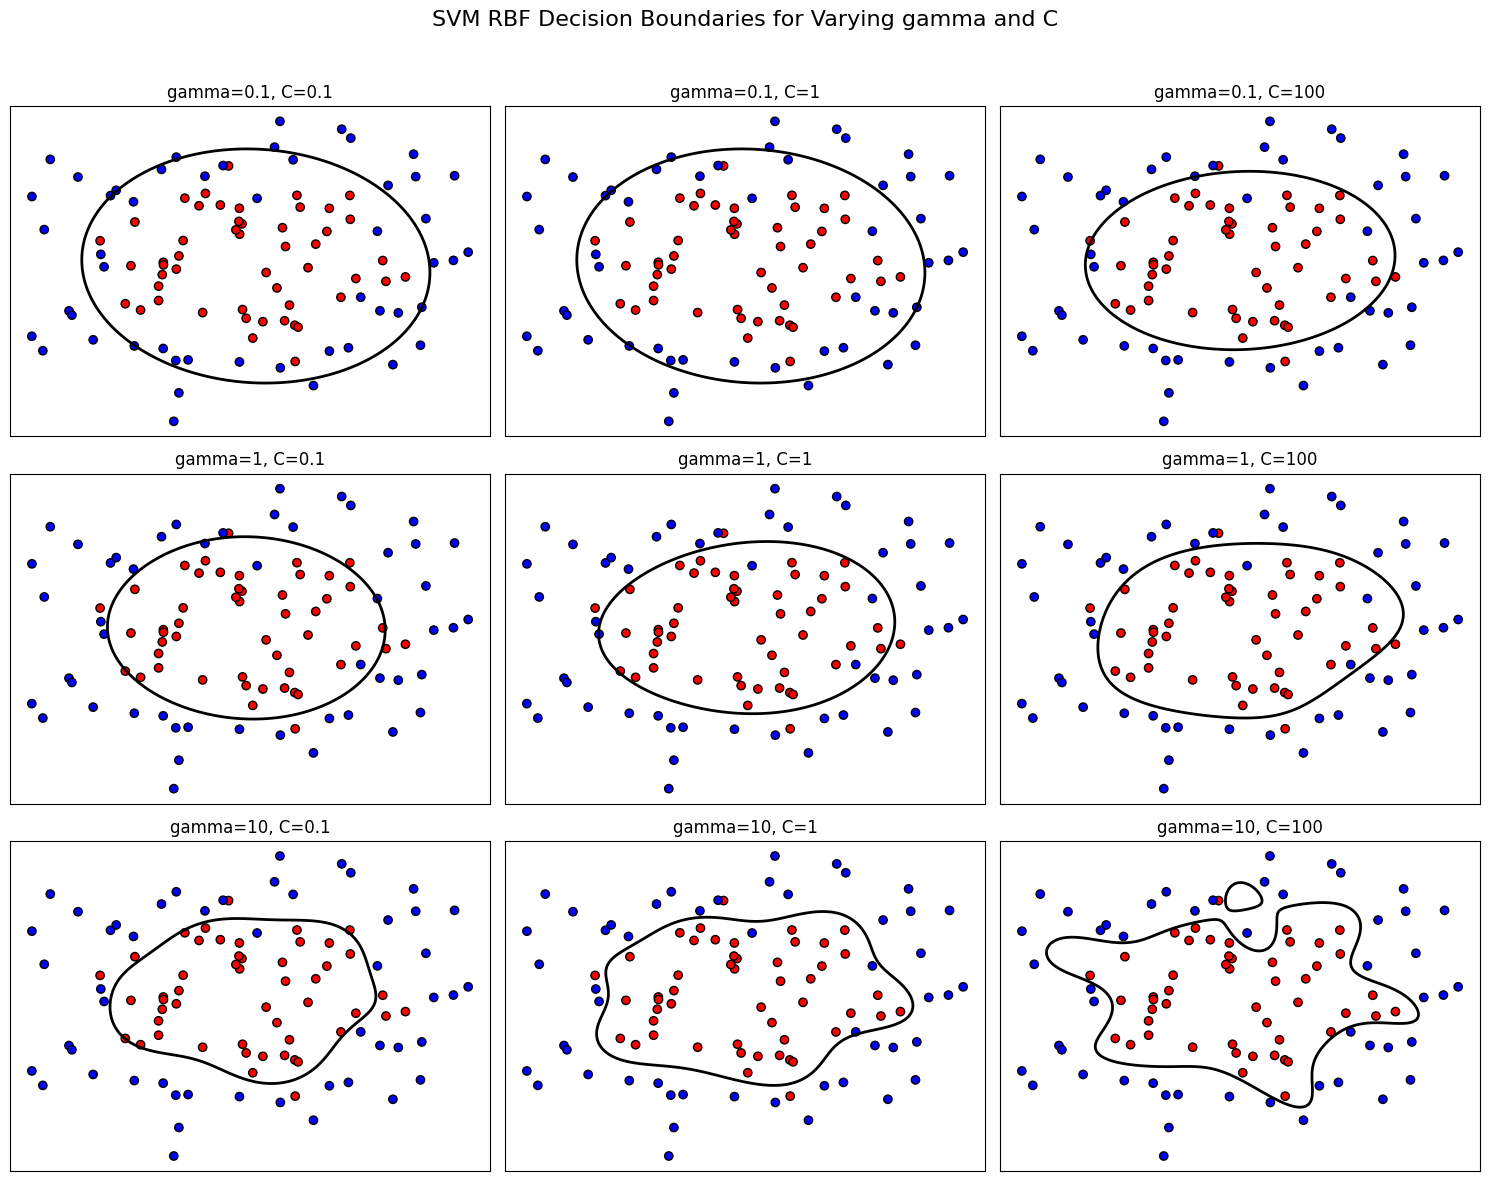

In [7]:
# Step 6: Compare SVM decision boundaries for various gamma and C
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Parameter grid
gamma_values = [0.1, 1, 10]
C_values = [0.1, 1, 100]

for i, gamma in enumerate(gamma_values):
    for j, C_val in enumerate(C_values):
        ax = axes[i, j]
        svm = SVC(kernel='rbf', C=C_val, gamma=gamma)
        svm.fit(X, y)

        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')

        # Create grid for decision boundary
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx = np.linspace(xlim[0], xlim[1], 200)
        yy = np.linspace(ylim[0], ylim[1], 200)
        YY, XX = np.meshgrid(yy, xx)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T
        Z = svm.decision_function(xy).reshape(XX.shape)

        # Plot decision boundary
        ax.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')
        ax.set_title(f"gamma={gamma}, C={C_val}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("SVM RBF Decision Boundaries for Varying gamma and C", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Step 7: Hyperparameter Tuning Using GridSearchCV

We use `GridSearchCV` to automatically find the best \((C, \gamma)\) by:

- Trying all combinations of parameters on the training set.
- Evaluating with 5-fold cross-validation.
- Selecting the parameter pair with the highest average validation score.

This step improves model performance by systematic tuning.


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10]
}

# Setup SVM with RBF kernel
svm = SVC(kernel='rbf')

# GridSearchCV with 5-fold cross-validation
grid = GridSearchCV(svm, param_grid, cv=5)
grid.fit(X_train, y_train)

# Print best parameters
print("Best parameters found by grid search:", grid.best_params_)

# Evaluate on test set
print("\nTest set score: {:.2f}".format(grid.score(X_test, y_test)))

# Detailed classification report
y_pred = grid.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best parameters found by grid search: {'C': 10, 'gamma': 10}

Test set score: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.88      0.88      0.88        16

    accuracy                           0.84        25
   macro avg       0.83      0.83      0.83        25
weighted avg       0.84      0.84      0.84        25

